In [1]:
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv(
    "dataset/KDDTrain+.TXT",
    header=None
)

train_data.head()

PermissionError: [Errno 13] Permission denied: 'dataset/KDDTrain+.TXT'

In [ ]:
import os

print(os.getcwd())
print(os.listdir("dataset"))

In [3]:
import os

print(os.listdir("dataset/KDDTrain+.txt"))

['KDDTrain+.txt']


In [4]:
train_data = pd.read_csv(
    "dataset/KDDTrain+.txt/KDDTrain+.txt",
    header=None
)

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
print("Training Dataset Shape:", train_data.shape)


Training Dataset Shape: (125973, 43)


In [6]:
column_names = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train_data.columns = column_names

train_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
import os

print(os.listdir("dataset/KDDTest+.txt"))

['KDDTest+.txt']


In [8]:
test_data = pd.read_csv(
    "dataset/KDDTest+.txt/KDDTest+.txt",
    header=None
)

test_data.columns = column_names

test_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [9]:
print("Testing Dataset Shape:", test_data.shape)

Testing Dataset Shape: (22544, 43)


In [10]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [11]:
train_data.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [12]:
print("Duplicate Records:", train_data.duplicated().sum())

Duplicate Records: 0


In [13]:
train_data["label"].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [14]:
print("Normal Records:", (train_data["label"] == "normal").sum())

Normal Records: 67343


In [15]:
print("Attack Records:", (train_data["label"] != "normal").sum())

Attack Records: 58630


In [16]:
train_data["target"] = train_data["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

train_data[["label", "target"]].head()

,label,target
0,normal,0
1,normal,0
2,neptune,1
3,normal,0
4,normal,0


In [17]:
train_data["target"].value_counts()

target
0    67343
1    58630
Name: count, dtype: int64

In [18]:
test_data["target"] = test_data["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_data["target"].value_counts()

target
1    12833
0     9711
Name: count, dtype: int64

In [19]:
X_train = train_data.drop(columns=["label", "difficulty", "target"])

y_train = train_data["target"]

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

X_train Shape: (125973, 41)
y_train Shape: (125973,)


In [20]:
X_test = test_data.drop(columns=["label", "difficulty", "target"])

y_test = test_data["target"]

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_test Shape: (22544, 41)
y_test Shape: (22544,)


In [21]:
categorical_columns = X_train.select_dtypes(include="object").columns

print(categorical_columns)

Index(['protocol_type', 'service', 'flag'], dtype='str')


C:\Users\Navya sri\AppData\Local\Temp\ipykernel_15904\2169016163.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include="object").columns


In [22]:
# Training and testing data combine cheyyadam
combined_data = pd.concat([X_train, X_test])

# One-Hot Encoding
combined_encoded = pd.get_dummies(
    combined_data,
    columns=["protocol_type", "service", "flag"]
)

# Malli train and test ga separate cheyyadam
X_train_encoded = combined_encoded.iloc[:len(X_train)]
X_test_encoded = combined_encoded.iloc[len(X_train):]

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X_train shape: (125973, 122)
Encoded X_test shape: (22544, 122)


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train_encoded, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [24]:
# Make predictions on test data
y_pred = model.predict(X_test_encoded)

print("Prediction completed!")

Prediction completed!


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Model Accuracy: 0.7650372604684174
Accuracy Percentage: 76.50372604684173


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.77      0.76     22544



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9445  266]
 [5031 7802]]


In [28]:
#gradient
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

print("Gradient Boosting Model Training Completed!")

Gradient Boosting Model Training Completed!


In [29]:
gb_y_pred = gb_model.predict(X_test_encoded)

print("Prediction completed!")

Prediction completed!


In [30]:
from sklearn.metrics import accuracy_score

gb_accuracy = accuracy_score(y_test, gb_y_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Accuracy Percentage:", gb_accuracy * 100)

Gradient Boosting Accuracy: 0.8072657913413769
Accuracy Percentage: 80.7265791341377


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_y_pred))

              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [32]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train)

print("XGBoost Model Training Completed!")

XGBoost Model Training Completed!


In [34]:
xgb_y_pred = xgb_model.predict(X_test_encoded)

print("XGBoost Prediction Completed!")

XGBoost Prediction Completed!


In [35]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print("Accuracy Percentage:", xgb_accuracy * 100)

XGBoost Accuracy: 0.7868168914123492
Accuracy Percentage: 78.68168914123493


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



In [37]:
from sklearn.metrics import confusion_matrix

gb_cm = confusion_matrix(y_test, gb_y_pred)

print(gb_cm)

[[9457  254]
 [4091 8742]]


In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_model_improved = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_model_improved.fit(X_train_encoded, y_train)

print("Improved Gradient Boosting Training Completed!")

Improved Gradient Boosting Training Completed!


In [39]:
gb_improved_pred = gb_model_improved.predict(X_test_encoded)

gb_improved_accuracy = accuracy_score(
    y_test,
    gb_improved_pred
)

print("Improved Accuracy:", gb_improved_accuracy)
print("Accuracy Percentage:", gb_improved_accuracy * 100)

Improved Accuracy: 0.809749822569198
Accuracy Percentage: 80.9749822569198


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_improved_pred))

              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [41]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.1}

Best Cross Validation Accuracy:
0.9984282346217047


In [42]:
# Best model
best_gb_model = random_search.best_estimator_

# Test dataset prediction
best_gb_pred = best_gb_model.predict(X_test_encoded)

# Test accuracy
best_gb_accuracy = accuracy_score(y_test, best_gb_pred)

print("Best Gradient Boosting Test Accuracy:", best_gb_accuracy)
print("Accuracy Percentage:", best_gb_accuracy * 100)

Best Gradient Boosting Test Accuracy: 0.8094836763662172
Accuracy Percentage: 80.94836763662173


In [43]:
print(classification_report(y_test, best_gb_pred))

              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [44]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": gb_model_improved.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,src_bytes,0.719373
56,service_ecr_i,0.073353
65,service_http,0.055185
2,dst_bytes,0.044732
30,dst_host_same_srv_rate,0.027290
6,hot,0.022515
8,logged_in,0.009210
32,dst_host_same_src_port_rate,0.007789
90,service_private,0.005430
19,count,0.005415


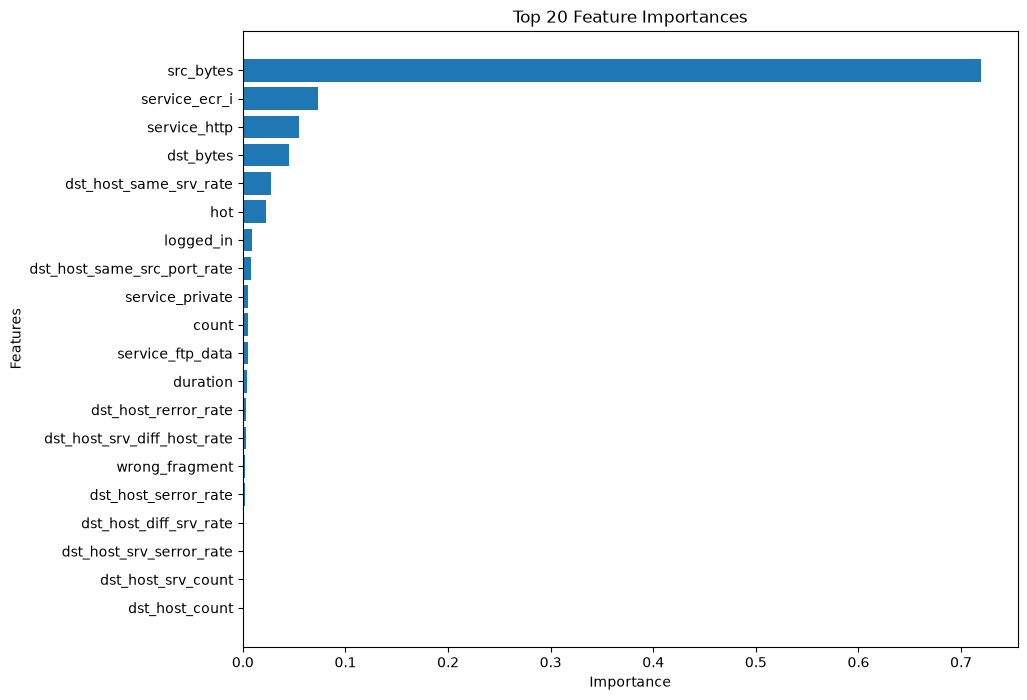

In [45]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [46]:
top_20_features = feature_importance.head(20)["Feature"].tolist()

X_train_top20 = X_train_encoded[top_20_features]
X_test_top20 = X_test_encoded[top_20_features]

print(X_train_top20.shape)
print(X_test_top20.shape)

(125973, 20)
(22544, 20)


In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_top20 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_top20.fit(X_train_top20, y_train)

top20_pred = gb_top20.predict(X_test_top20)

top20_accuracy = accuracy_score(y_test, top20_pred)

print("Top 20 Features Accuracy:", top20_accuracy * 100)

Top 20 Features Accuracy: 79.65312278211498


In [48]:
top_30_features = feature_importance.head(30)["Feature"].tolist()

X_train_top30 = X_train_encoded[top_30_features]
X_test_top30 = X_test_encoded[top_30_features]

gb_top30 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_top30.fit(X_train_top30, y_train)

top30_pred = gb_top30.predict(X_test_top30)

top30_accuracy = accuracy_score(y_test, top30_pred)

print("Top 30 Features Accuracy:", top30_accuracy * 100)

Top 30 Features Accuracy: 80.09669978708304


In [49]:
top_50_features = feature_importance.head(50)["Feature"].tolist()

X_train_top50 = X_train_encoded[top_50_features]
X_test_top50 = X_test_encoded[top_50_features]

gb_top50 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_top50.fit(X_train_top50, y_train)

top50_pred = gb_top50.predict(X_test_top50)

top50_accuracy = accuracy_score(y_test, top50_pred)

print("Top 50 Features Accuracy:", top50_accuracy * 100)

Top 50 Features Accuracy: 80.52253371185238


In [50]:
results = pd.DataFrame({
    "Features Used": ["All 122", "Top 20", "Top 30", "Top 50"],
    "Accuracy": [
        80.9749822569198,
        top20_accuracy * 100,
        top30_accuracy * 100,
        top50_accuracy * 100
    ]
})

results

,Features Used,Accuracy
0,All 122,80.974982
1,Top 20,79.653123
2,Top 30,80.096700
3,Top 50,80.522534


In [51]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
categorical_columns = ["protocol_type", "service", "flag"]

In [53]:
from catboost import CatBoostClassifier

categorical_columns = ["protocol_type", "service", "flag"]

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns
)

print("CatBoost Model Training Completed!")

0:	learn: 0.9690013	total: 301ms	remaining: 2m 30s
100:	learn: 0.9986584	total: 9.18s	remaining: 36.3s
200:	learn: 0.9988966	total: 16.4s	remaining: 24.5s
300:	learn: 0.9988966	total: 22.3s	remaining: 14.8s
400:	learn: 0.9988887	total: 29.5s	remaining: 7.28s
499:	learn: 0.9988887	total: 37.2s	remaining: 0us
CatBoost Model Training Completed!


In [54]:
import sys

print(sys.executable)

C:\Program Files\Python313\python.exe


In [55]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "catboost"
])

0

In [56]:
from catboost import CatBoostClassifier

print("CatBoost imported successfully!")

CatBoost imported successfully!


In [57]:
import sys
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "catboost"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)


Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



In [58]:
from catboost import CatBoostClassifier

print("CatBoost imported successfully!")

CatBoost imported successfully!


In [59]:
from catboost import CatBoostClassifier

categorical_columns = [
    "protocol_type",
    "service",
    "flag"
]

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns
)

print("CatBoost Model Training Completed!")

0:	learn: 0.9690013	total: 100ms	remaining: 50.1s
100:	learn: 0.9986584	total: 9.31s	remaining: 36.8s
200:	learn: 0.9988966	total: 17.1s	remaining: 25.4s
300:	learn: 0.9988966	total: 25s	remaining: 16.5s
400:	learn: 0.9988887	total: 37.6s	remaining: 9.28s
499:	learn: 0.9988887	total: 53.9s	remaining: 0us
CatBoost Model Training Completed!


In [60]:
cat_y_pred = cat_model.predict(X_test)

print("CatBoost Prediction Completed!")

CatBoost Prediction Completed!


In [61]:
from sklearn.metrics import accuracy_score

cat_accuracy = accuracy_score(y_test, cat_y_pred)

print("CatBoost Accuracy:", cat_accuracy)
print("Accuracy Percentage:", cat_accuracy * 100)

CatBoost Accuracy: 0.7987934705464869
Accuracy Percentage: 79.87934705464869


In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, cat_y_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [63]:
gb_probabilities = gb_model_improved.predict_proba(X_test_encoded)

attack_probabilities = gb_probabilities[:, 1]

print(attack_probabilities[:10])


[9.99298382e-01 9.99231942e-01 7.77803403e-03 8.61532629e-01
 5.50466931e-01 9.44186007e-04 7.92607942e-03 3.14347620e-03
 8.87969837e-04 3.50701109e-03]


In [64]:
print(X_train.shape)
print(X_test.shape)

(125973, 41)
(22544, 41)


In [65]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(125973, 122)
(22544, 122)


In [66]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model_improved = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_model_improved.fit(X_train_encoded, y_train)

print("Improved Gradient Boosting Model Training Completed!")

Improved Gradient Boosting Model Training Completed!


In [67]:
gb_y_pred = gb_model_improved.predict(X_test_encoded)

print("Prediction completed!")

Prediction completed!


In [68]:
from sklearn.metrics import accuracy_score

gb_accuracy = accuracy_score(y_test, gb_y_pred)

print("Current Accuracy:", gb_accuracy)
print("Accuracy Percentage:", gb_accuracy * 100)

Current Accuracy: 0.809749822569198
Accuracy Percentage: 80.9749822569198


In [69]:
gb_probabilities = gb_model_improved.predict_proba(X_test_encoded)

attack_probabilities = gb_probabilities[:, 1]

print("Probabilities generated!")

Probabilities generated!


In [70]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds:

    predictions = (attack_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.2
Accuracy: 84.19%
Attack Recall: 74.46%
F1 Score: 84.28%

Threshold: 0.3
Accuracy: 82.51%
Attack Recall: 71.45%
F1 Score: 82.31%

Threshold: 0.4
Accuracy: 81.72%
Attack Recall: 70.03%
F1 Score: 81.35%

Threshold: 0.5
Accuracy: 80.97%
Attack Recall: 68.69%
F1 Score: 80.43%

Threshold: 0.6
Accuracy: 79.36%
Attack Recall: 65.85%
F1 Score: 78.41%

Threshold: 0.7
Accuracy: 78.52%
Attack Recall: 64.35%
F1 Score: 77.33%

Threshold: 0.8
Accuracy: 76.89%
Attack Recall: 61.45%
F1 Score: 75.17%


In [71]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]

for threshold in thresholds:

    predictions = (attack_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.05
Accuracy: 87.16%
Attack Recall: 80.35%
F1 Score: 87.69%

Threshold: 0.1
Accuracy: 85.76%
Attack Recall: 77.43%
F1 Score: 86.09%

Threshold: 0.15
Accuracy: 84.87%
Attack Recall: 75.71%
F1 Score: 85.06%

Threshold: 0.2
Accuracy: 84.19%
Attack Recall: 74.46%
F1 Score: 84.28%

Threshold: 0.25
Accuracy: 82.73%
Attack Recall: 71.84%
F1 Score: 82.56%


In [72]:
thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]

for threshold in thresholds:

    predictions = (attack_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.01
Accuracy: 87.25%
Attack Recall: 86.67%
F1 Score: 88.56%

Threshold: 0.02
Accuracy: 86.44%
Attack Recall: 82.83%
F1 Score: 87.42%

Threshold: 0.03
Accuracy: 86.28%
Attack Recall: 82.08%
F1 Score: 87.20%

Threshold: 0.04
Accuracy: 87.73%
Attack Recall: 81.45%
F1 Score: 88.31%

Threshold: 0.05
Accuracy: 87.16%
Attack Recall: 80.35%
F1 Score: 87.69%

Threshold: 0.06
Accuracy: 86.80%
Attack Recall: 79.58%
F1 Score: 87.28%

Threshold: 0.07
Accuracy: 86.45%
Attack Recall: 78.91%
F1 Score: 86.89%


In [73]:
thresholds = [
    0.032, 0.034, 0.036, 0.038,
    0.040, 0.042, 0.044, 0.046, 0.048
]

results = []

for threshold in thresholds:

    predictions = (attack_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([threshold, accuracy, recall, f1])

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.032
Accuracy: 87.66%
Attack Recall: 81.92%
F1 Score: 88.31%

Threshold: 0.034
Accuracy: 87.61%
Attack Recall: 81.80%
F1 Score: 88.25%

Threshold: 0.036
Accuracy: 87.58%
Attack Recall: 81.72%
F1 Score: 88.22%

Threshold: 0.038
Accuracy: 87.83%
Attack Recall: 81.63%
F1 Score: 88.42%

Threshold: 0.04
Accuracy: 87.73%
Attack Recall: 81.45%
F1 Score: 88.31%

Threshold: 0.042
Accuracy: 87.71%
Attack Recall: 81.37%
F1 Score: 88.29%

Threshold: 0.044
Accuracy: 87.53%
Attack Recall: 81.04%
F1 Score: 88.09%

Threshold: 0.046
Accuracy: 87.49%
Attack Recall: 80.96%
F1 Score: 88.05%

Threshold: 0.048
Accuracy: 87.37%
Attack Recall: 80.73%
F1 Score: 87.92%


In [74]:
from sklearn.metrics import confusion_matrix, classification_report

best_threshold = 0.038

best_predictions = (
    attack_probabilities >= best_threshold
).astype(int)

cm = confusion_matrix(y_test, best_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Confusion Matrix:
[[ 9325   386]
 [ 2357 10476]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      9711
           1       0.96      0.82      0.88     12833

    accuracy                           0.88     22544
   macro avg       0.88      0.89      0.88     22544
weighted avg       0.89      0.88      0.88     22544



In [75]:
# Train lo unna attack labels
train_attacks = set(
    train_data.loc[train_data["target"] == 1, "label"].unique()
)

# Test lo unna attack labels
test_attacks = set(
    test_data.loc[test_data["target"] == 1, "label"].unique()
)

# Test lo unna but Train lo leni attacks
unseen_attacks = test_attacks - train_attacks

print("Number of Train Attack Types:", len(train_attacks))
print("Number of Test Attack Types:", len(test_attacks))

print("\nUnseen Attack Types in Test Data:")
print(sorted(unseen_attacks))

Number of Train Attack Types: 22
Number of Test Attack Types: 37

Unseen Attack Types in Test Data:
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [76]:
unseen_test_records = test_data[
    test_data["label"].isin(unseen_attacks)
]

print("Number of Unseen Attack Records:")
print(len(unseen_test_records))

print("\nUnseen Attack Distribution:")
print(unseen_test_records["label"].value_counts())

Number of Unseen Attack Records:
3750

Unseen Attack Distribution:
label
mscan            996
apache2          737
processtable     685
snmpguess        331
saint            319
mailbomb         293
snmpgetattack    178
httptunnel       133
named             17
ps                15
sendmail          14
xterm             13
xlock              9
xsnoop             4
worm               2
sqlattack          2
udpstorm           2
Name: count, dtype: int64


In [77]:
# Best threshold predictions
best_threshold = 0.038

best_predictions = (
    attack_probabilities >= best_threshold
).astype(int)

# Unseen attack records mask
unseen_mask = test_data["label"].isin(unseen_attacks)

# Accuracy / detection rate on unseen attacks
unseen_detection_rate = best_predictions[unseen_mask].mean()

print("Unseen Attack Detection Rate:",
      unseen_detection_rate * 100)

print("\nDetected Unseen Attacks:",
      best_predictions[unseen_mask].sum())

print("Total Unseen Attack Records:",
      unseen_mask.sum())

Unseen Attack Detection Rate: 74.69333333333333

Detected Unseen Attacks: 2801
Total Unseen Attack Records: 3750


In [78]:
# Add predictions to a copy of test data
analysis_data = test_data.copy()

analysis_data["prediction"] = best_predictions

# Only attack records
attack_analysis = analysis_data[analysis_data["target"] == 1]

# Detection rate for each attack type
attack_detection = attack_analysis.groupby("label")["prediction"].agg(
    Total="count",
    Detected="sum"
)

attack_detection["Detection_Rate"] = (
    attack_detection["Detected"] / attack_detection["Total"] * 100
)

# Sort from worst detection rate to best
attack_detection = attack_detection.sort_values(
    "Detection_Rate"
)

print(attack_detection)

                 Total  Detected  Detection_Rate
label                                           
snmpgetattack      178         0        0.000000
worm                 2         0        0.000000
xlock                9         0        0.000000
guess_passwd      1231         3        0.243704
mailbomb           293         8        2.730375
sendmail            14         1        7.142857
rootkit             13         3       23.076923
xsnoop               4         1       25.000000
named               17         5       29.411765
phf                  2         1       50.000000
multihop            18         9       50.000000
processtable       685       404       58.978102
ps                  15         9       60.000000
xterm               13         9       69.230769
buffer_overflow     20        16       80.000000
httptunnel         133       111       83.458647
warezmaster        944       789       83.580508
snmpguess          331       288       87.009063
apache2            7

In [79]:
guess_mask = test_data["label"] == "guess_passwd"

guess_probabilities = attack_probabilities[guess_mask]

print("Number of guess_passwd records:", len(guess_probabilities))

print("\nProbability Statistics:")
print("Minimum:", guess_probabilities.min())
print("Maximum:", guess_probabilities.max())
print("Average:", guess_probabilities.mean())

print("\nFirst 20 probabilities:")
print(guess_probabilities[:20])

Number of guess_passwd records: 1231

Probability Statistics:
Minimum: 0.0008681942458138119
Maximum: 0.08402999844235223
Average: 0.0033137439527929392

First 20 probabilities:
[0.00314348 0.00350701 0.00105409 0.00105409 0.00410107 0.00314348
 0.00121393 0.00549742 0.00091327 0.00819838 0.00206882 0.00410107
 0.00438171 0.00127193 0.00269508 0.00131792 0.00088681 0.00314348
 0.00228462 0.00496499]


In [80]:
thresholds = [
    0.001, 0.002, 0.003, 0.004, 0.005,
    0.006, 0.008, 0.01, 0.02, 0.038
]

for threshold in thresholds:

    predictions = (attack_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.001
Accuracy: 83.29%
Attack Recall: 98.02%
F1 Score: 86.98%

Threshold: 0.002
Accuracy: 86.93%
Attack Recall: 95.04%
F1 Score: 89.22%

Threshold: 0.003
Accuracy: 86.82%
Attack Recall: 91.58%
F1 Score: 88.78%

Threshold: 0.004
Accuracy: 87.03%
Attack Recall: 90.24%
F1 Score: 88.79%

Threshold: 0.005
Accuracy: 87.04%
Attack Recall: 89.25%
F1 Score: 88.69%

Threshold: 0.006
Accuracy: 87.12%
Attack Recall: 88.54%
F1 Score: 88.67%

Threshold: 0.008
Accuracy: 87.60%
Attack Recall: 87.97%
F1 Score: 88.98%

Threshold: 0.01
Accuracy: 87.25%
Attack Recall: 86.67%
F1 Score: 88.56%

Threshold: 0.02
Accuracy: 86.44%
Attack Recall: 82.83%
F1 Score: 87.42%

Threshold: 0.038
Accuracy: 87.83%
Attack Recall: 81.63%
F1 Score: 88.42%


In [81]:
best_threshold = 0.038

best_predictions = (
    attack_probabilities >= best_threshold
).astype(int)

best_accuracy = accuracy_score(y_test, best_predictions)

print("Best Threshold:", best_threshold)
print("Best Accuracy:", best_accuracy * 100)

Best Threshold: 0.038
Best Accuracy: 87.83268275372605


In [82]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [83]:
hist_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=300,
    max_leaf_nodes=31,
    random_state=42
)

hist_model.fit(X_train_encoded, y_train)

print("HistGradientBoosting Model Training Completed!")

HistGradientBoosting Model Training Completed!


In [84]:
from sklearn.metrics import accuracy_score, classification_report

hist_y_pred = hist_model.predict(X_test_encoded)

hist_accuracy = accuracy_score(y_test, hist_y_pred)

print("HistGradientBoosting Accuracy:", hist_accuracy)
print("Accuracy Percentage:", hist_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, hist_y_pred))

HistGradientBoosting Accuracy: 0.8001685592618879
Accuracy Percentage: 80.0168559261888

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [85]:
# Get probabilities
hist_probabilities = hist_model.predict_proba(X_test_encoded)

attack_probabilities_hist = hist_probabilities[:, 1]

# Test thresholds
thresholds = [
    0.001, 0.002, 0.005, 0.01,
    0.02, 0.03, 0.04, 0.05,
    0.1, 0.2, 0.3
]

for threshold in thresholds:

    predictions = (attack_probabilities_hist >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.001
Accuracy: 87.55%
Attack Recall: 85.85%
F1 Score: 88.70%

Threshold: 0.002
Accuracy: 86.67%
Attack Recall: 83.30%
F1 Score: 87.68%

Threshold: 0.005
Accuracy: 85.34%
Attack Recall: 80.11%
F1 Score: 86.15%

Threshold: 0.01
Accuracy: 86.32%
Attack Recall: 78.64%
F1 Score: 86.75%

Threshold: 0.02
Accuracy: 85.58%
Attack Recall: 77.19%
F1 Score: 85.90%

Threshold: 0.03
Accuracy: 84.39%
Attack Recall: 75.00%
F1 Score: 84.55%

Threshold: 0.04
Accuracy: 83.88%
Attack Recall: 74.02%
F1 Score: 83.94%

Threshold: 0.05
Accuracy: 83.49%
Attack Recall: 73.32%
F1 Score: 83.49%

Threshold: 0.1
Accuracy: 82.74%
Attack Recall: 71.95%
F1 Score: 82.60%

Threshold: 0.2
Accuracy: 81.60%
Attack Recall: 69.91%
F1 Score: 81.23%

Threshold: 0.3
Accuracy: 80.96%
Attack Recall: 68.74%
F1 Score: 80.43%


In [86]:
ensemble_probabilities = (
    attack_probabilities + attack_probabilities_hist
) / 2

In [87]:
thresholds = [
    0.001, 0.002, 0.005, 0.008,
    0.01, 0.02, 0.03, 0.04,
    0.05, 0.06, 0.08, 0.1
]

for threshold in thresholds:

    predictions = (ensemble_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.001
Accuracy: 87.27%
Attack Recall: 95.68%
F1 Score: 89.54%

Threshold: 0.002
Accuracy: 87.57%
Attack Recall: 91.30%
F1 Score: 89.32%

Threshold: 0.005
Accuracy: 87.65%
Attack Recall: 87.58%
F1 Score: 88.98%

Threshold: 0.008
Accuracy: 87.21%
Attack Recall: 85.46%
F1 Score: 88.38%

Threshold: 0.01
Accuracy: 87.41%
Attack Recall: 84.72%
F1 Score: 88.45%

Threshold: 0.02
Accuracy: 88.86%
Attack Recall: 83.53%
F1 Score: 89.51%

Threshold: 0.03
Accuracy: 88.11%
Attack Recall: 82.01%
F1 Score: 88.70%

Threshold: 0.04
Accuracy: 87.81%
Attack Recall: 81.34%
F1 Score: 88.37%

Threshold: 0.05
Accuracy: 87.29%
Attack Recall: 80.28%
F1 Score: 87.79%

Threshold: 0.06
Accuracy: 87.01%
Attack Recall: 79.69%
F1 Score: 87.48%

Threshold: 0.08
Accuracy: 85.89%
Attack Recall: 77.59%
F1 Score: 86.22%

Threshold: 0.1
Accuracy: 85.71%
Attack Recall: 77.22%
F1 Score: 86.02%


In [88]:
thresholds = [
    0.012, 0.014, 0.016, 0.018,
    0.020, 0.022, 0.024, 0.026, 0.028
]

for threshold in thresholds:

    predictions = (ensemble_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.012
Accuracy: 87.31%
Attack Recall: 84.28%
F1 Score: 88.32%

Threshold: 0.014
Accuracy: 87.33%
Attack Recall: 84.14%
F1 Score: 88.32%

Threshold: 0.016
Accuracy: 87.34%
Attack Recall: 83.99%
F1 Score: 88.31%

Threshold: 0.018
Accuracy: 87.15%
Attack Recall: 83.64%
F1 Score: 88.11%

Threshold: 0.02
Accuracy: 88.86%
Attack Recall: 83.53%
F1 Score: 89.51%

Threshold: 0.022
Accuracy: 88.84%
Attack Recall: 83.48%
F1 Score: 89.49%

Threshold: 0.024
Accuracy: 88.49%
Attack Recall: 82.82%
F1 Score: 89.12%

Threshold: 0.026
Accuracy: 88.40%
Attack Recall: 82.58%
F1 Score: 89.01%

Threshold: 0.028
Accuracy: 88.28%
Attack Recall: 82.33%
F1 Score: 88.89%


In [89]:
thresholds = [
    0.0180, 0.0185, 0.0190, 0.0195,
    0.0200, 0.0205, 0.0210, 0.0215, 0.0220
]

for threshold in thresholds:

    predictions = (ensemble_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.018
Accuracy: 87.15%
Attack Recall: 83.64%
F1 Score: 88.11%

Threshold: 0.0185
Accuracy: 87.15%
Attack Recall: 83.62%
F1 Score: 88.10%

Threshold: 0.019
Accuracy: 87.17%
Attack Recall: 83.59%
F1 Score: 88.12%

Threshold: 0.0195
Accuracy: 88.87%
Attack Recall: 83.58%
F1 Score: 89.53%

Threshold: 0.02
Accuracy: 88.86%
Attack Recall: 83.53%
F1 Score: 89.51%

Threshold: 0.0205
Accuracy: 88.85%
Attack Recall: 83.52%
F1 Score: 89.51%

Threshold: 0.021
Accuracy: 88.85%
Attack Recall: 83.50%
F1 Score: 89.51%

Threshold: 0.0215
Accuracy: 88.84%
Attack Recall: 83.49%
F1 Score: 89.50%

Threshold: 0.022
Accuracy: 88.84%
Attack Recall: 83.48%
F1 Score: 89.49%


In [90]:
# Different ensemble weights

weights = [
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7)
]

best_result = []

for gb_weight, hist_weight in weights:

    weighted_probabilities = (
        gb_weight * attack_probabilities
        + hist_weight * attack_probabilities_hist
    )

    # Current best threshold
    predictions = (
        weighted_probabilities >= 0.0195
    ).astype(int)

    accuracy = accuracy_score(y_test, predictions)

    print(
        f"GB: {gb_weight}, HistGB: {hist_weight} "
        f"→ Accuracy: {accuracy * 100:.2f}%"
    )

    best_result.append(
        (gb_weight, hist_weight, accuracy)
    )

print("\nBest Weight Combination:")
print(max(best_result, key=lambda x: x[2]))

GB: 0.9, HistGB: 0.1 → Accuracy: 86.81%
GB: 0.8, HistGB: 0.2 → Accuracy: 86.88%
GB: 0.7, HistGB: 0.3 → Accuracy: 87.02%
GB: 0.6, HistGB: 0.4 → Accuracy: 87.15%
GB: 0.5, HistGB: 0.5 → Accuracy: 88.87%
GB: 0.4, HistGB: 0.6 → Accuracy: 88.62%
GB: 0.3, HistGB: 0.7 → Accuracy: 88.41%

Best Weight Combination:
(0.5, 0.5, 0.8886621717530163)


In [91]:
from sklearn.ensemble import ExtraTreesClassifier

extra_model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

extra_model.fit(X_train_encoded, y_train)

print("Extra Trees Model Training Completed!")

Extra Trees Model Training Completed!


In [92]:
from sklearn.metrics import accuracy_score, classification_report

extra_y_pred = extra_model.predict(X_test_encoded)

extra_accuracy = accuracy_score(y_test, extra_y_pred)

print("Extra Trees Accuracy:", extra_accuracy)
print("Accuracy Percentage:", extra_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, extra_y_pred))

Extra Trees Accuracy: 0.7876153300212917
Accuracy Percentage: 78.76153300212917

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



In [93]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_encoded,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training data shape:", X_train_final.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (100778, 122)
Validation data shape: (25195, 122)


In [94]:
from sklearn.ensemble import GradientBoostingClassifier

gb_validation_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_validation_model.fit(X_train_final, y_train_final)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [95]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_validation_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=300,
    max_leaf_nodes=31,
    random_state=42
)

hist_validation_model.fit(X_train_final, y_train_final)

print("HistGradientBoosting training completed!")

HistGradientBoosting training completed!


In [96]:
# Gradient Boosting validation probabilities
gb_val_probabilities = gb_validation_model.predict_proba(X_val)[:, 1]

# HistGradientBoosting validation probabilities
hist_val_probabilities = hist_validation_model.predict_proba(X_val)[:, 1]

# 50-50 Ensemble
ensemble_val_probabilities = (
    0.5 * gb_val_probabilities +
    0.5 * hist_val_probabilities
)

print("Validation probabilities generated successfully!")

Validation probabilities generated successfully!


In [97]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

thresholds = [
    0.001, 0.002, 0.005, 0.008,
    0.01, 0.015, 0.02, 0.025,
    0.03, 0.04, 0.05
]

results = []

for threshold in thresholds:

    val_predictions = (
        ensemble_val_probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(y_val, val_predictions)
    recall = recall_score(y_val, val_predictions)
    f1 = f1_score(y_val, val_predictions)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "recall": recall,
        "f1": f1
    })

    print(f"\nThreshold: {threshold}")
    print(f"Validation Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.001
Validation Accuracy: 83.91%
Attack Recall: 100.00%
F1 Score: 85.26%

Threshold: 0.002
Validation Accuracy: 88.73%
Attack Recall: 100.00%
F1 Score: 89.20%

Threshold: 0.005
Validation Accuracy: 96.03%
Attack Recall: 100.00%
F1 Score: 95.91%

Threshold: 0.008
Validation Accuracy: 97.80%
Attack Recall: 100.00%
F1 Score: 97.69%

Threshold: 0.01
Validation Accuracy: 98.37%
Attack Recall: 100.00%
F1 Score: 98.28%

Threshold: 0.015
Validation Accuracy: 98.94%
Attack Recall: 99.99%
F1 Score: 98.87%

Threshold: 0.02
Validation Accuracy: 99.16%
Attack Recall: 99.97%
F1 Score: 99.10%

Threshold: 0.025
Validation Accuracy: 99.31%
Attack Recall: 99.97%
F1 Score: 99.26%

Threshold: 0.03
Validation Accuracy: 99.43%
Attack Recall: 99.97%
F1 Score: 99.39%

Threshold: 0.04
Validation Accuracy: 99.54%
Attack Recall: 99.97%
F1 Score: 99.50%

Threshold: 0.05
Validation Accuracy: 99.60%
Attack Recall: 99.97%
F1 Score: 99.57%


In [98]:
# Final ensemble probabilities on test set
final_gb_probabilities = gb_validation_model.predict_proba(
    X_test_encoded
)[:, 1]

final_hist_probabilities = hist_validation_model.predict_proba(
    X_test_encoded
)[:, 1]

final_ensemble_probabilities = (
    0.5 * final_gb_probabilities +
    0.5 * final_hist_probabilities
)

# Best threshold selected from validation
best_threshold = 0.05

final_predictions = (
    final_ensemble_probabilities >= best_threshold
).astype(int)

# Final evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_accuracy = accuracy_score(y_test, final_predictions)

print("Final Test Accuracy:", final_accuracy)
print("Accuracy Percentage:", final_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))


Final Test Accuracy: 0.8632008516678495
Accuracy Percentage: 86.32008516678495

Confusion Matrix:
[[ 9372   339]
 [ 2745 10088]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      9711
           1       0.97      0.79      0.87     12833

    accuracy                           0.86     22544
   macro avg       0.87      0.88      0.86     22544
weighted avg       0.88      0.86      0.86     22544



In [99]:
# Features to analyze
features_to_compare = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "diff_srv_rate"
]

# Worst attack types
worst_attacks = [
    "guess_passwd",
    "mailbomb",
    "snmpgetattack",
    "processtable"
]

# Normal traffic averages
normal_data = test_data[test_data["label"] == "normal"]

normal_means = normal_data[features_to_compare].mean()

print("===== NORMAL TRAFFIC AVERAGES =====")
print(normal_means)

===== NORMAL TRAFFIC AVERAGES =====
duration           47.068376
src_bytes        2530.512512
dst_bytes        4165.124601
count              37.479353
srv_count          40.821131
serror_rate         0.003181
same_srv_rate       0.982477
diff_srv_rate       0.017023
dtype: float64


In [100]:
for attack in worst_attacks:

    attack_data = test_data[
        test_data["label"] == attack
    ]

    attack_means = attack_data[
        features_to_compare
    ].mean()

    comparison = pd.DataFrame({
        "Normal": normal_means,
        attack: attack_means
    })

    print("\n" + "=" * 50)
    print("ATTACK TYPE:", attack)
    print("=" * 50)

    print(comparison)


ATTACK TYPE: guess_passwd
                    Normal  guess_passwd
duration         47.068376      2.865150
src_bytes      2530.512512     58.561332
dst_bytes      4165.124601    147.311942
count            37.479353      1.103981
srv_count        40.821131      1.069050
serror_rate       0.003181      0.003249
same_srv_rate     0.982477      0.983136
diff_srv_rate     0.017023      0.031275

ATTACK TYPE: mailbomb
                    Normal     mailbomb
duration         47.068376     1.061433
src_bytes      2530.512512  2599.000000
dst_bytes      4165.124601   291.907850
count            37.479353     2.617747
srv_count        40.821131     2.491468
serror_rate       0.003181     0.000000
same_srv_rate     0.982477     0.958464
diff_srv_rate     0.017023     0.083038

ATTACK TYPE: snmpgetattack
                    Normal  snmpgetattack
duration         47.068376      67.977528
src_bytes      2530.512512     106.831461
dst_bytes      4165.124601     137.488764
count            37.47935

In [101]:
for attack in worst_attacks:

    attack_data = test_data[
        test_data["label"] == attack
    ]

    attack_means = attack_data[
        features_to_compare
    ].mean()

    comparison = pd.DataFrame({
        "Normal": normal_means,
        attack: attack_means
    })

    comparison["Difference"] = (
        attack_means - normal_means
    )

    print("\n" + "=" * 60)
    print(f"NORMAL vs {attack}")
    print("=" * 60)

    print(comparison)


NORMAL vs guess_passwd
                    Normal  guess_passwd   Difference
duration         47.068376      2.865150   -44.203226
src_bytes      2530.512512     58.561332 -2471.951179
dst_bytes      4165.124601    147.311942 -4017.812659
count            37.479353      1.103981   -36.375373
srv_count        40.821131      1.069050   -39.752081
serror_rate       0.003181      0.003249     0.000068
same_srv_rate     0.982477      0.983136     0.000659
diff_srv_rate     0.017023      0.031275     0.014252

NORMAL vs mailbomb
                    Normal     mailbomb   Difference
duration         47.068376     1.061433   -46.006943
src_bytes      2530.512512  2599.000000    68.487488
dst_bytes      4165.124601   291.907850 -3873.216751
count            37.479353     2.617747   -34.861606
srv_count        40.821131     2.491468   -38.329663
serror_rate       0.003181     0.000000    -0.003181
same_srv_rate     0.982477     0.958464    -0.024012
diff_srv_rate     0.017023     0.083038     0.

In [104]:
X_train_encoded["byte_ratio"] = (
    X_train_encoded["src_bytes"] /
    (X_train_encoded["dst_bytes"] + 1)
)

In [105]:
print(X_train_encoded.columns.tolist())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'se

In [106]:
def add_new_features(df):
    df = df.copy()

    # Total bytes
    df["total_bytes"] = (
        df["src_bytes"] + df["dst_bytes"]
    )

    # Connection difference
    df["connection_difference"] = (
        abs(df["count"] - df["srv_count"])
    )

    # Error rate difference
    df["error_rate_difference"] = (
        abs(df["serror_rate"] - df["srv_serror_rate"])
    )

    return df


# Apply features
X_train_fe = add_new_features(X_train_encoded)
X_val_fe = add_new_features(X_val)
X_test_fe = add_new_features(X_test_encoded)

print("Feature Engineering Completed!")

print("Train Shape:", X_train_fe.shape)
print("Validation Shape:", X_val_fe.shape)
print("Test Shape:", X_test_fe.shape)

Feature Engineering Completed!
Train Shape: (125973, 126)
Validation Shape: (25195, 125)
Test Shape: (22544, 125)


In [107]:
print("byte_ratio in Train:", "byte_ratio" in X_train_encoded.columns)
print("byte_ratio in Validation:", "byte_ratio" in X_val.columns)
print("byte_ratio in Test:", "byte_ratio" in X_test_encoded.columns)

byte_ratio in Train: True
byte_ratio in Validation: False
byte_ratio in Test: False


In [108]:
# Add byte_ratio to Validation data
X_val["byte_ratio"] = (
    X_val["src_bytes"] /
    (X_val["dst_bytes"] + 1)
)

# Add byte_ratio to Test data
X_test_encoded["byte_ratio"] = (
    X_test_encoded["src_bytes"] /
    (X_test_encoded["dst_bytes"] + 1)
)

print("byte_ratio added successfully!")

byte_ratio added successfully!


In [109]:
print("Train:", X_train_encoded.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_encoded.shape)

print("\nbyte_ratio check:")
print("Train:", "byte_ratio" in X_train_encoded.columns)
print("Validation:", "byte_ratio" in X_val.columns)
print("Test:", "byte_ratio" in X_test_encoded.columns)

Train: (125973, 123)
Validation: (25195, 123)
Test: (22544, 123)

byte_ratio check:
Train: True
Validation: True
Test: True


In [110]:
def add_new_features(df):
    df = df.copy()

    # Total network bytes
    df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]

    # Difference between count and service count
    df["connection_difference"] = abs(
        df["count"] - df["srv_count"]
    )

    # Difference between error rates
    df["error_rate_difference"] = abs(
        df["serror_rate"] - df["srv_serror_rate"]
    )

    return df


X_train_fe = add_new_features(X_train_encoded)
X_val_fe = add_new_features(X_val)
X_test_fe = add_new_features(X_test_encoded)

print("Feature Engineering Completed!")
print("Train:", X_train_fe.shape)
print("Validation:", X_val_fe.shape)
print("Test:", X_test_fe.shape)

Feature Engineering Completed!
Train: (125973, 126)
Validation: (25195, 126)
Test: (22544, 126)


In [111]:
from sklearn.ensemble import GradientBoostingClassifier

gb_fe_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_fe_model.fit(X_train_fe, y_train)

print("Feature Engineered Gradient Boosting Training Completed!")

Feature Engineered Gradient Boosting Training Completed!


In [112]:
from sklearn.metrics import accuracy_score, classification_report

# Validation predictions
gb_fe_val_pred = gb_fe_model.predict(X_val_fe)

# Validation accuracy
gb_fe_val_accuracy = accuracy_score(y_val, gb_fe_val_pred)

print("Feature Engineered GB Validation Accuracy:",
      gb_fe_val_accuracy)

print("Accuracy Percentage:",
      gb_fe_val_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_val, gb_fe_val_pred))

Feature Engineered GB Validation Accuracy: 0.9993252629489978
Accuracy Percentage: 99.93252629489979

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [113]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test predictions
gb_fe_test_pred = gb_fe_model.predict(X_test_fe)

# Test accuracy
gb_fe_test_accuracy = accuracy_score(y_test, gb_fe_test_pred)

print("Feature Engineered GB Test Accuracy:",
      gb_fe_test_accuracy)

print("Accuracy Percentage:",
      gb_fe_test_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_fe_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_fe_test_pred))

Feature Engineered GB Test Accuracy: 0.8069109297374024
Accuracy Percentage: 80.69109297374024

Confusion Matrix:
[[9433  278]
 [4075 8758]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [114]:
features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "diff_srv_rate"
]

comparison = pd.DataFrame({
    "Train_Mean": X_train_encoded[features].mean(),
    "Test_Mean": X_test_encoded[features].mean(),
    "Train_Median": X_train_encoded[features].median(),
    "Test_Median": X_test_encoded[features].median()
})

comparison["Mean_Difference"] = (
    comparison["Test_Mean"] - comparison["Train_Mean"]
)

print(comparison)

                 Train_Mean     Test_Mean  Train_Median  Test_Median  \
duration         287.144650    218.859076           0.0          0.0   
src_bytes      45566.743000  10395.450231          44.0         54.0   
dst_bytes      19779.114421   2056.018808           0.0         46.0   
count             84.107555     79.028345          14.0          8.0   
srv_count         27.737888     31.124379           8.0          6.0   
serror_rate        0.284485      0.102924           0.0          0.0   
same_srv_rate      0.660928      0.740345           1.0          1.0   
diff_srv_rate      0.063053      0.094074           0.0          0.0   

               Mean_Difference  
duration            -68.285574  
src_bytes        -35171.292770  
dst_bytes        -17723.095614  
count                -5.079210  
srv_count             3.386491  
serror_rate          -0.181561  
same_srv_rate         0.079417  
diff_srv_rate         0.031021  


In [115]:
import numpy as np

def log_transform_features(df):
    df = df.copy()

    features_to_log = [
        "duration",
        "src_bytes",
        "dst_bytes",
        "count",
        "srv_count"
    ]

    for feature in features_to_log:
        df[feature] = np.log1p(df[feature])

    return df


X_train_log = log_transform_features(X_train_encoded)
X_val_log = log_transform_features(X_val)
X_test_log = log_transform_features(X_test_encoded)

print("Log transformation completed!")

Log transformation completed!


In [116]:
from sklearn.ensemble import GradientBoostingClassifier

gb_log_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_log_model.fit(X_train_log, y_train)

print("Log-transformed Gradient Boosting training completed!")

Log-transformed Gradient Boosting training completed!


In [117]:
from sklearn.metrics import accuracy_score, classification_report

# Validation predictions
gb_log_val_pred = gb_log_model.predict(X_val_log)

# Validation accuracy
gb_log_val_accuracy = accuracy_score(y_val, gb_log_val_pred)

print("Log-Transformed GB Validation Accuracy:", gb_log_val_accuracy)
print("Accuracy Percentage:", gb_log_val_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_val, gb_log_val_pred))

Log-Transformed GB Validation Accuracy: 0.999285572534233
Accuracy Percentage: 99.9285572534233

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [118]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test predictions
gb_log_test_pred = gb_log_model.predict(X_test_log)

# Test accuracy
gb_log_test_accuracy = accuracy_score(y_test, gb_log_test_pred)

print("Log-Transformed GB Test Accuracy:", gb_log_test_accuracy)
print("Accuracy Percentage:", gb_log_test_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_log_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_log_test_pred))

Log-Transformed GB Test Accuracy: 0.8116572036905607
Accuracy Percentage: 81.16572036905607

Confusion Matrix:
[[9434  277]
 [3969 8864]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.97      0.82      9711
           1       0.97      0.69      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.86      0.81      0.81     22544



In [119]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# Create sample weights
sample_weights = np.where(
    y_train == 1,
    2.0,   # Attack class ki higher importance
    1.0    # Normal class
)

print("Normal weight:", 1.0)
print("Attack weight:", 2.0)

# Model
gb_weighted_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train using sample weights
gb_weighted_model.fit(
    X_train_encoded,
    y_train,
    sample_weight=sample_weights
)

print("Weighted Gradient Boosting Training Completed!")

Normal weight: 1.0
Attack weight: 2.0
Weighted Gradient Boosting Training Completed!


In [120]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Validation predictions
gb_weighted_val_pred = gb_weighted_model.predict(X_val)

# Validation accuracy
val_accuracy = accuracy_score(y_val, gb_weighted_val_pred)

print("Weighted GB Validation Accuracy:", val_accuracy)
print("Accuracy Percentage:", val_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_weighted_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, gb_weighted_val_pred))

Weighted GB Validation Accuracy: 0.9991268108751736
Accuracy Percentage: 99.91268108751737

Confusion Matrix:
[[13455    14]
 [    8 11718]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [121]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test predictions
gb_weighted_test_pred = gb_weighted_model.predict(X_test_encoded)

# Test accuracy
test_accuracy = accuracy_score(y_test, gb_weighted_test_pred)

print("Weighted GB Test Accuracy:", test_accuracy)
print("Accuracy Percentage:", test_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_weighted_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_weighted_test_pred))

Weighted GB Test Accuracy: 0.8191092973740242
Accuracy Percentage: 81.91092973740241

Confusion Matrix:
[[9429  282]
 [3796 9037]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.97      0.82      9711
           1       0.97      0.70      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544



In [123]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# Attack class weight = 3
sample_weights_3 = np.where(
    y_train == 1,
    3.0,
    1.0
)

gb_weighted_3_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_weighted_3_model.fit(
    X_train_encoded,
    y_train,
    sample_weight=sample_weights_3
)

print("Weighted GB (Attack Weight = 3) Training Completed!")

Weighted GB (Attack Weight = 3) Training Completed!


In [124]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Validation predictions
gb_weighted_3_val_pred = gb_weighted_3_model.predict(X_val)

# Validation accuracy
val_accuracy_3 = accuracy_score(y_val, gb_weighted_3_val_pred)

print("Weighted GB (Weight = 3) Validation Accuracy:", val_accuracy_3)
print("Accuracy Percentage:", val_accuracy_3 * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_weighted_3_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, gb_weighted_3_val_pred))

Weighted GB (Weight = 3) Validation Accuracy: 0.9990077396308792
Accuracy Percentage: 99.90077396308791

Confusion Matrix:
[[13450    19]
 [    6 11720]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [125]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test predictions
gb_weighted_3_test_pred = gb_weighted_3_model.predict(X_test_encoded)

# Test accuracy
test_accuracy_3 = accuracy_score(y_test, gb_weighted_3_test_pred)

print("Weighted GB (Weight = 3) Test Accuracy:", test_accuracy_3)
print("Accuracy Percentage:", test_accuracy_3 * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_weighted_3_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_weighted_3_test_pred))

Weighted GB (Weight = 3) Test Accuracy: 0.8144073811213627
Accuracy Percentage: 81.44073811213627

Confusion Matrix:
[[9428  283]
 [3901 8932]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.97      0.82      9711
           1       0.97      0.70      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.86      0.81      0.81     22544



In [126]:
print(hist_model)

HistGradientBoostingClassifier(max_iter=300, random_state=42)


In [127]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Get probability predictions
weighted_gb_val_prob = gb_weighted_model.predict_proba(X_val)[:, 1]
hist_val_prob = hist_model.predict_proba(X_val)[:, 1]

# 50-50 Ensemble probabilities
ensemble_val_prob = (
    0.5 * weighted_gb_val_prob +
    0.5 * hist_val_prob
)

# Default threshold
ensemble_val_pred = (ensemble_val_prob >= 0.5).astype(int)

# Accuracy
ensemble_val_accuracy = accuracy_score(y_val, ensemble_val_pred)

print("Weighted GB + HistGB Validation Accuracy:",
      ensemble_val_accuracy)

print("Accuracy Percentage:",
      ensemble_val_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_val, ensemble_val_pred))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- byte_ratio


In [128]:
# HistGB model training appudu unna features
hist_features = [
    col for col in X_val.columns
    if col != "byte_ratio"
]

# Validation data without byte_ratio
X_val_hist = X_val[hist_features]

print("Validation shape for HistGB:", X_val_hist.shape)

Validation shape for HistGB: (25195, 122)


In [130]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Weighted GB probabilities
weighted_gb_val_prob = gb_weighted_model.predict_proba(X_val)[:, 1]

# HistGB probabilities without byte_ratio
hist_val_prob = hist_model.predict_proba(X_val_hist)[:, 1]

# 50-50 ensemble
ensemble_val_prob = (
    0.5 * weighted_gb_val_prob +
    0.5 * hist_val_prob
)

# Predictions
ensemble_val_pred = (
    ensemble_val_prob >= 0.5
).astype(int)

# Accuracy
ensemble_val_accuracy = accuracy_score(
    y_val,
    ensemble_val_pred
)

print(
    "Weighted GB + HistGB Validation Accuracy:",
    ensemble_val_accuracy
)

print(
    "Accuracy Percentage:",
    ensemble_val_accuracy * 100
)

print("\nClassification Report:")
print(classification_report(y_val, ensemble_val_pred))

Weighted GB + HistGB Validation Accuracy: 0.9999206191704704
Accuracy Percentage: 99.99206191704704

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [131]:
# HistGB training appudu unna features matrame
X_test_hist = X_test_encoded.drop(columns=["byte_ratio"])

print("Weighted GB Test shape:", X_test_encoded.shape)
print("HistGB Test shape:", X_test_hist.shape)

Weighted GB Test shape: (22544, 123)
HistGB Test shape: (22544, 122)


In [132]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Weighted GB probabilities
weighted_gb_test_prob = gb_weighted_model.predict_proba(
    X_test_encoded
)[:, 1]

# HistGB probabilities
hist_test_prob = hist_model.predict_proba(
    X_test_hist
)[:, 1]

# 50-50 Ensemble
ensemble_test_prob = (
    0.5 * weighted_gb_test_prob +
    0.5 * hist_test_prob
)

# Default threshold
ensemble_test_pred = (
    ensemble_test_prob >= 0.5
).astype(int)

# Evaluation
ensemble_test_accuracy = accuracy_score(
    y_test,
    ensemble_test_pred
)

print("Weighted GB + HistGB Test Accuracy:", ensemble_test_accuracy)
print("Accuracy Percentage:", ensemble_test_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ensemble_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, ensemble_test_pred))

Weighted GB + HistGB Test Accuracy: 0.8041163946061036
Accuracy Percentage: 80.41163946061036

Confusion Matrix:
[[9437  274]
 [4142 8691]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [133]:
variables_to_check = [
    "gb_model_improved",
    "gb_weighted_model",
    "hist_model",
    "cat_model"
]

for var in variables_to_check:
    print(var, "→", var in globals())

gb_model_improved → True
gb_weighted_model → True
hist_model → True
cat_model → True


In [134]:
# Check probability ranges for all available models

models = {
    "Improved GB": gb_model_improved,
    "Weighted GB": gb_weighted_model,
    "HistGB": hist_model,
    "CatBoost": cat_model
}

for name, model in models.items():
    print("\n" + "=" * 40)
    print(name)
    print("=" * 40)

    # HistGB ki byte_ratio remove cheyyali
    if name == "HistGB":
        X_data = X_test_encoded.drop(columns=["byte_ratio"])
    else:
        X_data = X_test_encoded

    probabilities = model.predict_proba(X_data)[:, 1]

    print("Min probability:", probabilities.min())
    print("Max probability:", probabilities.max())
    print("Mean probability:", probabilities.mean())


Improved GB


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- byte_ratio


In [135]:
# Improved GB ki required features
gb_features = list(gb_model_improved.feature_names_in_)

print("Improved GB expects:", len(gb_features), "features")

# Exact same features and same order
X_test_gb = X_test_encoded[gb_features]

print("Test data shape:", X_test_gb.shape)

Improved GB expects: 122 features
Test data shape: (22544, 122)


In [136]:
gb_improved_prob = gb_model_improved.predict_proba(X_test_gb)[:, 1]

print("Min probability:", gb_improved_prob.min())
print("Max probability:", gb_improved_prob.max())
print("Mean probability:", gb_improved_prob.mean())

Min probability: 0.0006916630956792861
Max probability: 0.9995464685223003
Mean probability: 0.40021954286472966


In [137]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

thresholds = [
    0.001, 0.002, 0.005, 0.008,
    0.01, 0.02, 0.03, 0.038,
    0.04, 0.05
]

for threshold in thresholds:

    predictions = (
        gb_improved_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Attack Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Threshold: 0.001
Accuracy: 83.29%
Attack Recall: 98.02%
F1 Score: 86.98%

Threshold: 0.002
Accuracy: 86.93%
Attack Recall: 95.04%
F1 Score: 89.22%

Threshold: 0.005
Accuracy: 87.04%
Attack Recall: 89.25%
F1 Score: 88.69%

Threshold: 0.008
Accuracy: 87.60%
Attack Recall: 87.97%
F1 Score: 88.98%

Threshold: 0.01
Accuracy: 87.25%
Attack Recall: 86.67%
F1 Score: 88.56%

Threshold: 0.02
Accuracy: 86.44%
Attack Recall: 82.83%
F1 Score: 87.42%

Threshold: 0.03
Accuracy: 86.28%
Attack Recall: 82.08%
F1 Score: 87.20%

Threshold: 0.038
Accuracy: 87.83%
Attack Recall: 81.63%
F1 Score: 88.42%

Threshold: 0.04
Accuracy: 87.73%
Attack Recall: 81.45%
F1 Score: 88.31%

Threshold: 0.05
Accuracy: 87.16%
Attack Recall: 80.35%
F1 Score: 87.69%


In [138]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Best threshold
best_threshold = 0.038

# Final predictions
final_predictions = (
    gb_improved_prob >= best_threshold
).astype(int)

# Final Accuracy
final_accuracy = accuracy_score(y_test, final_predictions)

print("FINAL MODEL RESULTS")
print("=" * 50)

print("Model: Improved Gradient Boosting")
print("Threshold:", best_threshold)
print(f"Final Accuracy: {final_accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))



FINAL MODEL RESULTS
Model: Improved Gradient Boosting
Threshold: 0.038
Final Accuracy: 87.83%

Confusion Matrix:
[[ 9325   386]
 [ 2357 10476]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      9711
           1       0.96      0.82      0.88     12833

    accuracy                           0.88     22544
   macro avg       0.88      0.89      0.88     22544
weighted avg       0.89      0.88      0.88     22544



In [139]:
import joblib

# Save the trained model
joblib.dump(
    gb_model_improved,
    "network_intrusion_model.pkl"
)

# Save required feature names
joblib.dump(
    gb_features,
    "model_features.pkl"
)

# Save best threshold
joblib.dump(
    best_threshold,
    "best_threshold.pkl"
)

print("Model saved successfully!")
print("Model file: network_intrusion_model.pkl")
print("Features file: model_features.pkl")
print("Threshold file: best_threshold.pkl")

Model saved successfully!
Model file: network_intrusion_model.pkl
Features file: model_features.pkl
Threshold file: best_threshold.pkl


In [140]:
# Test data lo first attack record select cheyyadam

attack_record = test_data[test_data["label"] != "normal"].iloc[0]

print("Attack Type:", attack_record["label"])

print("\nFrontend Testing Values:")
print("Protocol:", attack_record["protocol_type"])
print("Service:", attack_record["service"])
print("Flag:", attack_record["flag"])
print("Source Bytes:", attack_record["src_bytes"])
print("Destination Bytes:", attack_record["dst_bytes"])
print("Duration:", attack_record["duration"])

Attack Type: neptune

Frontend Testing Values:
Protocol: tcp
Service: private
Flag: REJ
Source Bytes: 0
Destination Bytes: 0
Duration: 0
